<a href="https://colab.research.google.com/github/Samuellucas97/Scripts-Mixed-Method/blob/main/Copy_of_CHI_DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [93]:
import pandas as pd
import numpy as np
import io
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")


In [94]:
from google.colab import files
uploaded = files.upload()


df = pd.read_csv(io.BytesIO(uploaded['data1.csv']))

Saving data1.csv to data1.csv


In [95]:
df.head()

,ID,Seniority Level,Simplified Seniority Level,SE tasks using LLMs,Organisation's AI Policy,Select your preferred working mode for each software development task. - Code generation,Select your preferred working mode for each software development task. - Code summarisation,Select your preferred working mode for each software development task. - Code search,Select your preferred working mode for each software development task. - Code completion,Select your preferred working mode for each software development task. - Code understanding,...,Rate the level of agreement with the following statements regarding Data analysis: - I trust the AI/GenAI/LLMs' actions to protect my interests and align with my values for this task.,"How strongly do you agree with the statement ""This is a long survey""? No matter your actual feelings, select strongly disagree.",Unnamed: 261,Unnamed: 262,Unnamed: 263,Unnamed: 264,Unnamed: 265,Unnamed: 266,Unnamed: 267,Unnamed: 268
0,SP1,Junior,Novice,"Code generation,Code search,Code translation,A...","Yes, there is a policy and it supports the usa...",Partial delegation,NaN,Partial delegation,NaN,NaN,...,NaN,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SP2,Mid-level,Novice,"Code understanding,Code translation","Yes, there is a policy and it supports the usa...",NaN,NaN,NaN,NaN,Partial delegation,...,NaN,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SP3,Mid-level,Novice,"Code generation,Code summarisation,Code unders...","No, there is no policy;",Partial delegation,Partial delegation,NaN,NaN,Partial delegation,...,NaN,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SP4,Mid-level,Novice,"Code summarisation,Code completion,Code transl...","Yes, there is a policy and it supports the usa...",NaN,Partial delegation,NaN,Self-delegation,NaN,...,Strongly agree,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SP5,Mid-level,Novice,"Code generation,Code translation,API document ...","Yes, there is a policy and it supports the usa...",Partial delegation,NaN,NaN,NaN,NaN,...,Strongly agree,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
df.head()

,id,senioritylevel,simplified seniority level,llm4setasks,llmpolice,select your preferred working mode for each software development task. - code generation,select your preferred working mode for each software development task. - code summarisation,select your preferred working mode for each software development task. - code search,select your preferred working mode for each software development task. - code completion,select your preferred working mode for each software development task. - code understanding,...,rate the level of agreement with the following statements regarding data analysis: - i trust the ai/genai/llms' actions to protect my interests and align with my values for this task.,"how strongly do you agree with the statement ""this is a long survey""? no matter your actual feelings, select strongly disagree.",unnamed: 261,unnamed: 262,unnamed: 263,unnamed: 264,unnamed: 265,unnamed: 266,unnamed: 267,unnamed: 268
0,SP1,Junior,Novice,"Code generation,Code search,Code translation,A...","Yes, there is a policy and it supports the usa...",Partial delegation,NaN,Partial delegation,NaN,NaN,...,NaN,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SP2,Mid-level,Novice,"Code understanding,Code translation","Yes, there is a policy and it supports the usa...",NaN,NaN,NaN,NaN,Partial delegation,...,NaN,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SP3,Mid-level,Novice,"Code generation,Code summarisation,Code unders...","No, there is no policy;",Partial delegation,Partial delegation,NaN,NaN,Partial delegation,...,NaN,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SP4,Mid-level,Novice,"Code summarisation,Code completion,Code transl...","Yes, there is a policy and it supports the usa...",NaN,Partial delegation,NaN,Self-delegation,NaN,...,Strongly agree,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SP5,Mid-level,Novice,"Code generation,Code translation,API document ...","Yes, there is a policy and it supports the usa...",Partial delegation,NaN,NaN,NaN,NaN,...,Strongly agree,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
df = df.rename(columns={
    'Seniority Level': 'seniorityLevel',
    "Organisation's AI Policy": 'LLMPolice',
    'SE tasks using LLMs': 'LLM4SETasks'
})

# Display the updated columns to verify
display(df[['seniorityLevel', 'LLMPolice', 'LLM4SETasks']].head())

,seniorityLevel,LLMPolice,LLM4SETasks
0,Junior,"Yes, there is a policy and it supports the usa...","Code generation,Code search,Code translation,A..."
1,Mid-level,"Yes, there is a policy and it supports the usa...","Code understanding,Code translation"
2,Mid-level,"No, there is no policy;","Code generation,Code summarisation,Code unders..."
3,Mid-level,"Yes, there is a policy and it supports the usa...","Code summarisation,Code completion,Code transl..."
4,Mid-level,"Yes, there is a policy and it supports the usa...","Code generation,Code translation,API document ..."


# Data Preprocessing

In [98]:
# Define the 17 tasks as per the study design
# Convert task names to lowercase to match df's column names
tasks = [
    'code generation', 'code summarisation', 'code search', 'code completion',
    'code understanding', 'code comment generation', 'code translation',
    'code representation', 'method name generation', 'api document smells',
    'api recommendation', 'api document augment',
    'api entity and relation extraction', 'type inference',
    'control flow graph generation', 'agile story point estimation',
    'data analysis'
]

# Define items for each construct
# All items are already in lowercase as per instruction and to match df's column names
item_map = {
    'risk': [
        'in the case of mistakes or failure on this task, someone needs to be held accountable.',
        'a complex or unpredictable environment/situation is likely to cause this task to fail.',
        'failure would result in a substantial negative impact on my life or the lives of others.'
    ],
    'trust': [
        'i trust the ai/genai/llms\' ability to reliably complete the task.',
        'understanding the reasons behind the ai/genai/llms\' actions is important for me to trust the ai/genai/llms on this task (e.g., explanations are necessary).',
        'i trust the ai/genai/llms\' actions to protect my interests and align with my values for this task.'
    ]
}


In [99]:
df.columns = df.columns.str.lower()
df.columns

Index(['id', 'senioritylevel', 'simplified seniority level', 'llm4setasks',
       'llmpolice',
       'select your preferred working mode for each software development task. - code generation',
       'select your preferred working mode for each software development task. - code summarisation',
       'select your preferred working mode for each software development task. - code search',
       'select your preferred working mode for each software development task. - code completion',
       'select your preferred working mode for each software development task. - code understanding',
       ...
       'rate the level of agreement with the following statements regarding data analysis: - i trust the ai/genai/llms' actions to protect my interests and align with my values for this task.',
       'how strongly do you agree with the statement "this is a long survey"? no matter your actual feelings, select strongly disagree.',
       'unnamed: 261', 'unnamed: 262', 'unnamed: 263', 'unnamed:

In [100]:
df.iloc[:, [22, 23, 24, 73, 74, 75]]

,rate the level of agreement with the following statements regarding code generation: - this task requires social skills to complete.,rate the level of agreement with the following statements regarding code generation: - this task requires creativity to complete.,rate the level of agreement with the following statements regarding code generation: - this task requires a great deal of time or effort to complete.,"rate the level of agreement with the following statements regarding code completion: - i am interested in learning how to master this task, not just in the completion of the task.",rate the level of agreement with the following statements regarding code completion: - i consider this task especially valuable or important; i would feel committed to completing this task because of the value it adds to my life or the lives of others.,rate the level of agreement with the following statements regarding code completion: - i trust the ai/genai/llms' ability to reliably complete the task.
0,Strongly disagree,Somewhat agree,Strongly agree,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Neither agree nor disagree,Somewhat agree,Somewhat agree,NaN,NaN,NaN
3,NaN,NaN,NaN,Strongly agree,Strongly agree,Strongly agree
4,Somewhat agree,Strongly agree,Somewhat agree,NaN,NaN,NaN
...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
# Map Likert scale strings to numeric values
likert_map = {
    'Strongly disagree': 1,
    'Somewhat disagree': 2,
    'Neither agree nor disagree': 3,
    'Somewhat agree': 4,
    'Strongly agree': 5
}

delegation_map = {
    'Self-delegation': 0,
    'No delegation': 0,
    'Partial delegation': 1,
    'Full delegation': 1
}


regression_rows = []
delegated=0

for _, row in df.iterrows():
    for task in tasks:
        delegation=0
        entry = {
            'id': row.get('id'),
            'senioritylevel': row.get('senioritylevel'),
            'llmpolice': row.get('llmpolice'),
            'task': task,
            'delegated': 3
        }

        scores = []
        for construct, items in item_map.items():
            for item in items:
                col_name = f'select your preferred working mode for each software development task. - {task}'
                if row[col_name] in delegation_map:
                    delegated = delegation_map[row[col_name]]
                    entry['delegated'] = delegated



                # Reconstruct the column name in lowercase
                col_name = f'rate the level of agreement with the following statements regarding {task}: - {item}'

                if col_name in df.columns:
                    val_str = row[col_name]
                    if pd.notna(val_str) and val_str in likert_map:
                        val_numeric = likert_map[val_str]
                        scores.append(val_numeric)
                        # Store individual item score
                        entry[item] = val_numeric

            if scores:
                # Use median for the aggregate construct score
                entry[construct] = np.median(scores)
            else:
                entry[construct] = np.nan

        # Only add rows where we have at least some task data
        if not pd.isna(entry.get('trust')):
            regression_rows.append(entry)



df_long = pd.DataFrame(regression_rows)
display(df_long)
print(f'Transformed to long format with {len(df_long)} observations.')

,id,senioritylevel,llmpolice,task,delegated,"in the case of mistakes or failure on this task, someone needs to be held accountable.",a complex or unpredictable environment/situation is likely to cause this task to fail.,failure would result in a substantial negative impact on my life or the lives of others.,risk,i trust the ai/genai/llms' ability to reliably complete the task.,"understanding the reasons behind the ai/genai/llms' actions is important for me to trust the ai/genai/llms on this task (e.g., explanations are necessary).",i trust the ai/genai/llms' actions to protect my interests and align with my values for this task.,trust
0,SP1,Junior,"Yes, there is a policy and it supports the usa...",code generation,1,2.0,4.0,5.0,4.0,2.0,3.0,3.0,3.0
1,SP1,Junior,"Yes, there is a policy and it supports the usa...",code search,1,2.0,3.0,3.0,3.0,4.0,4.0,4.0,3.5
2,SP1,Junior,"Yes, there is a policy and it supports the usa...",code translation,1,1.0,1.0,1.0,1.0,4.0,3.0,3.0,2.0
3,SP1,Junior,"Yes, there is a policy and it supports the usa...",api recommendation,1,1.0,1.0,1.0,1.0,5.0,5.0,5.0,3.0
4,SP1,Junior,"Yes, there is a policy and it supports the usa...",type inference,1,4.0,4.0,3.0,4.0,3.0,4.0,3.0,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,SP160,Senior,"Yes, there is a policy and it supports the usa...",api entity and relation extraction,1,5.0,4.0,4.0,4.0,5.0,4.0,5.0,4.5
901,SP160,Senior,"Yes, there is a policy and it supports the usa...",type inference,1,5.0,4.0,2.0,4.0,5.0,1.0,5.0,4.5
902,SP160,Senior,"Yes, there is a policy and it supports the usa...",control flow graph generation,1,5.0,4.0,2.0,4.0,5.0,1.0,5.0,4.5
903,SP160,Senior,"Yes, there is a policy and it supports the usa...",agile story point estimation,1,2.0,5.0,4.0,4.0,2.0,5.0,2.0,3.0


Transformed to long format with 905 observations.


In [102]:
# Map llmpolice values as requested
policy_map = {
    "No, there is no policy;": "No policy",
    "Yes, there is a policy and it doesn't support the usage": "Prohibit",
    "Yes, there is a policy and it supports the usage for ALL software engineering tasks": "Allow",
    "Yes, there is a policy and it supports the usage with limitation for certain software engineering tasks": "Restrict"
}

df_long['llmpolice'] = df_long['llmpolice'].replace(policy_map)

print("Updated llmpolice categories:")
display(df_long['llmpolice'].value_counts())
display(df_long.head(30))


presenceOrAbsenceLLMPolicy_map = {
    "No policy": 0,
    "Prohibit": 1,
    "Allow": 1,
    "Restrict": 1
}


df_long['presenceOfllmpolicy'] = df_long['llmpolice'].replace(presenceOrAbsenceLLMPolicy_map)



indices_to_drop = df_long[df_long['presenceOfllmpolicy'] == 'I don\'t know'].index
df_long.drop(indices_to_drop, inplace=True)


indices_to_drop = df_long[df_long['presenceOfllmpolicy'] == 'Prefer not say'].index
df_long.drop(indices_to_drop, inplace=True)


Updated llmpolice categories:


,count
llmpolice,
Restrict,370
Allow,346
No policy,149
Prohibit,24
I don't know,14
Prefer not say,2


,id,senioritylevel,llmpolice,task,delegated,"in the case of mistakes or failure on this task, someone needs to be held accountable.",a complex or unpredictable environment/situation is likely to cause this task to fail.,failure would result in a substantial negative impact on my life or the lives of others.,risk,i trust the ai/genai/llms' ability to reliably complete the task.,"understanding the reasons behind the ai/genai/llms' actions is important for me to trust the ai/genai/llms on this task (e.g., explanations are necessary).",i trust the ai/genai/llms' actions to protect my interests and align with my values for this task.,trust
0,SP1,Junior,Restrict,code generation,1,2.0,4.0,5.0,4.0,2.0,3.0,3.0,3.0
1,SP1,Junior,Restrict,code search,1,2.0,3.0,3.0,3.0,4.0,4.0,4.0,3.5
2,SP1,Junior,Restrict,code translation,1,1.0,1.0,1.0,1.0,4.0,3.0,3.0,2.0
3,SP1,Junior,Restrict,api recommendation,1,1.0,1.0,1.0,1.0,5.0,5.0,5.0,3.0
4,SP1,Junior,Restrict,type inference,1,4.0,4.0,3.0,4.0,3.0,4.0,3.0,3.5
5,SP1,Junior,Restrict,control flow graph generation,0,1.0,1.0,4.0,1.0,2.0,2.0,3.0,2.0
6,SP2,Mid-level,Restrict,code understanding,1,4.0,2.0,1.0,2.0,4.0,5.0,5.0,4.0
7,SP2,Mid-level,Restrict,code translation,1,3.0,3.0,2.0,3.0,4.0,4.0,4.0,3.5
8,SP3,Mid-level,No policy,code generation,1,1.0,4.0,1.0,1.0,2.0,5.0,2.0,2.0
9,SP3,Mid-level,No policy,code summarisation,1,1.0,2.0,1.0,1.0,4.0,5.0,2.0,2.0


In [103]:
df_long['presenceOfllmpolicy'].value_counts()

,count
presenceOfllmpolicy,
1,740
0,149


# Data Analysis - Using Junior/Mid-level/Senior as seniority level

In [104]:
summary_df = df_long.groupby(['senioritylevel', 'presenceOfllmpolicy']).agg({
    'trust': 'mean',
    'risk': 'mean',
    'id': 'nunique'
}).rename(columns={'id': 'participant_count'})

display(summary_df)

trust      risk  participant_count
senioritylevel presenceOfllmpolicy                                       
Junior         0                    3.763158  3.263158                  4
               1                    3.646907  3.311856                 31
Mid-level      0                    3.606557  3.245902                 13
               1                    3.971831  3.624413                 40
Senior         0                    3.478261  2.528986                 12
               1                    3.800300  3.483483                 55

## Descriptive Analysis

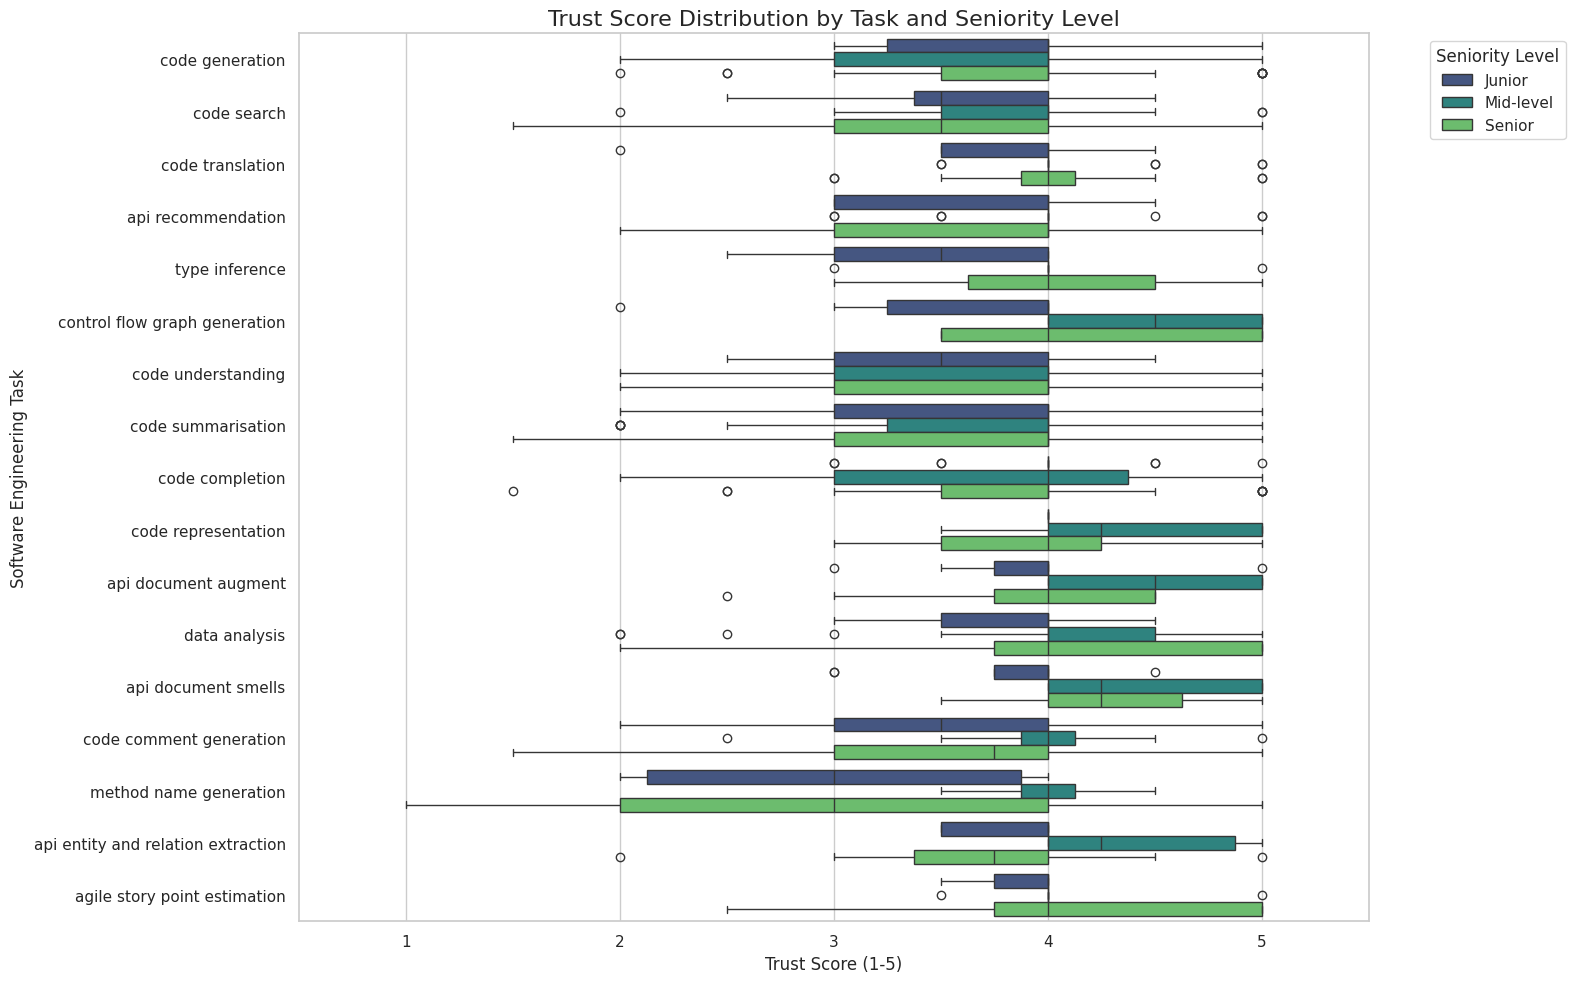

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Visualization: Trust by Task and Seniority Level
plt.figure(figsize=(16, 10))

# Create a boxplot to show distribution
sns.boxplot(
    data=df_long,
    x='trust',
    y='task',
    hue='senioritylevel',
    palette='viridis'
)

plt.title('Trust Score Distribution by Task and Seniority Level', fontsize=16)
plt.xlabel('Trust Score (1-5)', fontsize=12)
plt.ylabel('Software Engineering Task', fontsize=12)
plt.legend(title='Seniority Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0.5, 5.5)
plt.tight_layout()

plt.show()

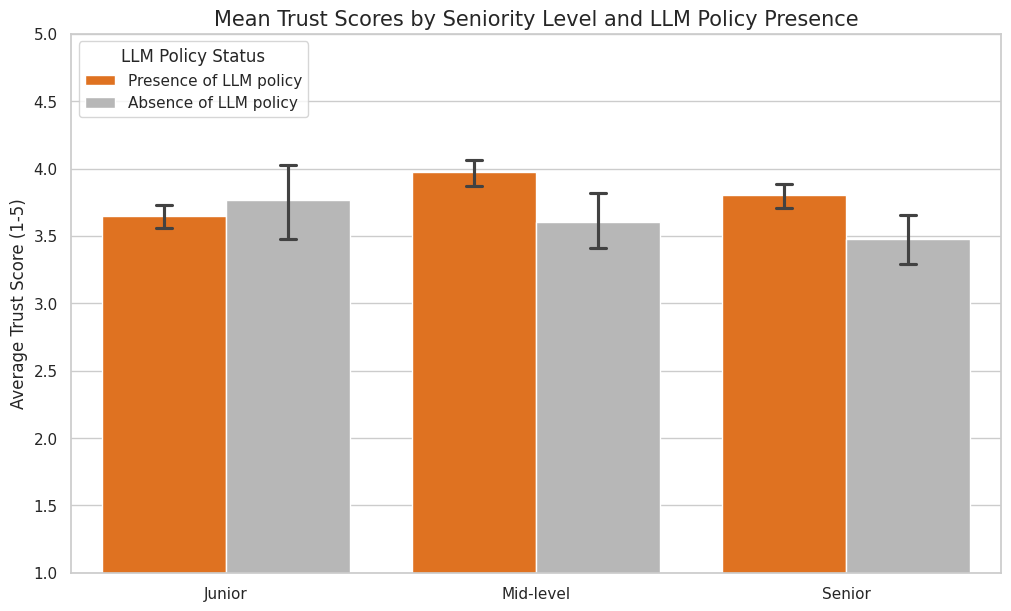

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy for visualization to map labels
plot_df = df_long.copy()
plot_df['presenceOfllmpolicy'] = plot_df['presenceOfllmpolicy'].map({0: 'Absence of LLM policy', 1: 'Presence of LLM policy'})

# Set style and seniority order
sns.set_theme(style="whitegrid")
seniority_order = ['Junior', 'Mid-level', 'Senior']

# Define custom color palette based on user hex codes
custom_palette = {
    'Presence of LLM policy': '#ff6d01',
    'Absence of LLM policy': '#b7b7b7'
}

# Create the visualization
plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x='senioritylevel',
    y='trust',
    hue='presenceOfllmpolicy',
    order=seniority_order,
    palette=custom_palette,
    capsize=.1
)

plt.title('Mean Trust Scores by Seniority Level and LLM Policy Presence', fontsize=15)
plt.xlabel('', fontsize=12)
plt.ylabel('Average Trust Score (1-5)', fontsize=12)
plt.legend(title='LLM Policy Status', loc='upper left')
plt.ylim(1, 5)
plt.show()

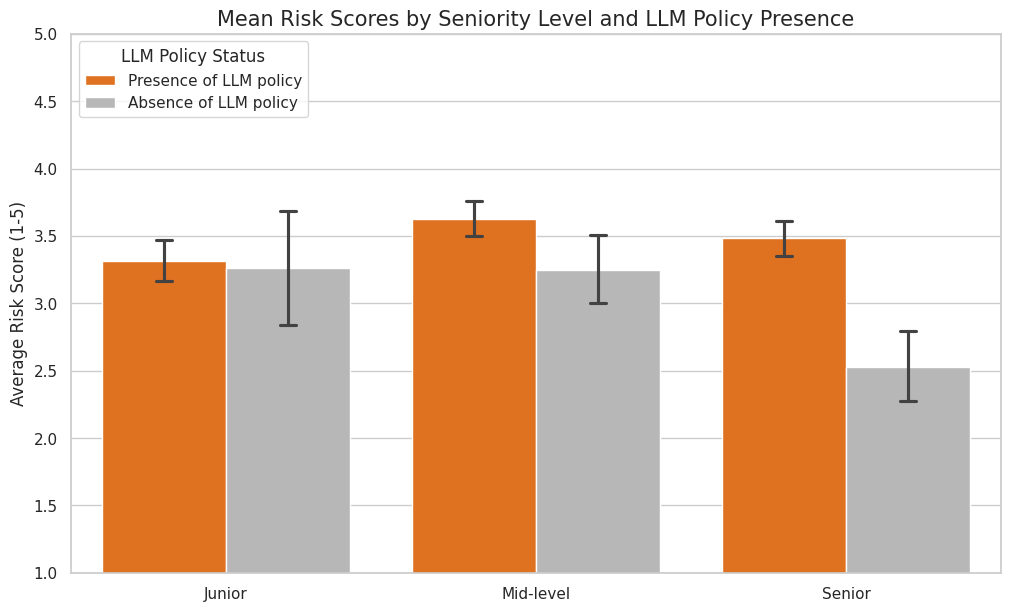

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy for visualization to map labels
plot_df = df_long.copy()
plot_df['presenceOfllmpolicy'] = plot_df['presenceOfllmpolicy'].map({0: 'Absence of LLM policy', 1: 'Presence of LLM policy'})

# Set style and seniority order
sns.set_theme(style="whitegrid")
seniority_order = ['Junior', 'Mid-level', 'Senior']

# Define custom color palette based on user hex codes
custom_palette = {
    'Presence of LLM policy': '#ff6d01',
    'Absence of LLM policy': '#b7b7b7'
}

# Create the visualization
plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x='senioritylevel',
    y='risk',
    hue='presenceOfllmpolicy',
    order=seniority_order,
    palette=custom_palette,
    capsize=.1
)

plt.title('Mean Risk Scores by Seniority Level and LLM Policy Presence', fontsize=15)
plt.xlabel('', fontsize=12)
plt.ylabel('Average Risk Score (1-5)', fontsize=12)
plt.legend(title='LLM Policy Status', loc='upper left')
plt.ylim(1, 5)
plt.show()

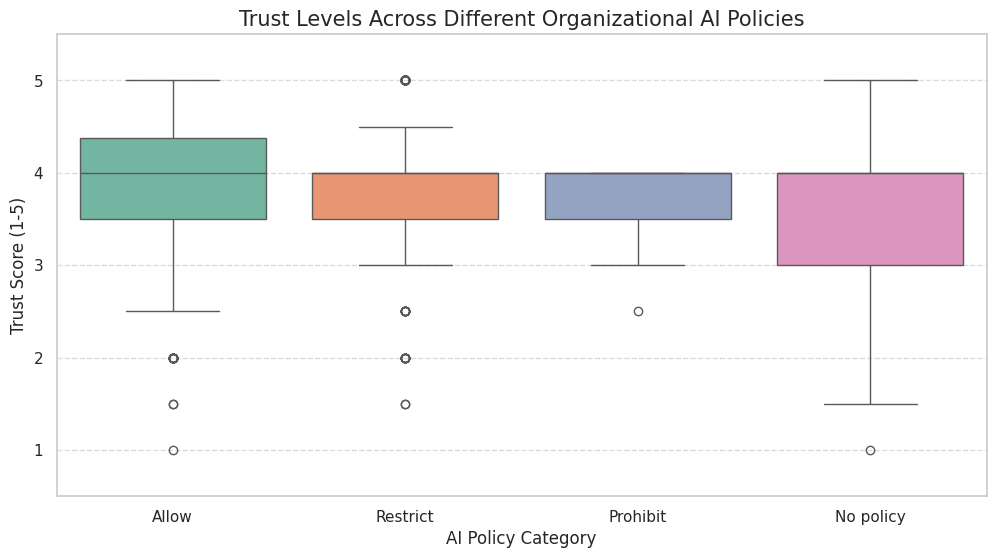

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out minor categories for a cleaner visualization
policy_subset = df_long[df_long['llmpolice'].isin(['Allow', 'Restrict', 'Prohibit', 'No policy'])]

plt.figure(figsize=(12, 6))
sns.boxplot(data=policy_subset, x='llmpolice', y='trust', palette='Set2', order=['Allow', 'Restrict', 'Prohibit', 'No policy'])

plt.title('Trust Levels Across Different Organizational AI Policies', fontsize=15)
plt.xlabel('AI Policy Category', fontsize=12)
plt.ylabel('Trust Score (1-5)', fontsize=12)
plt.ylim(0.5, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

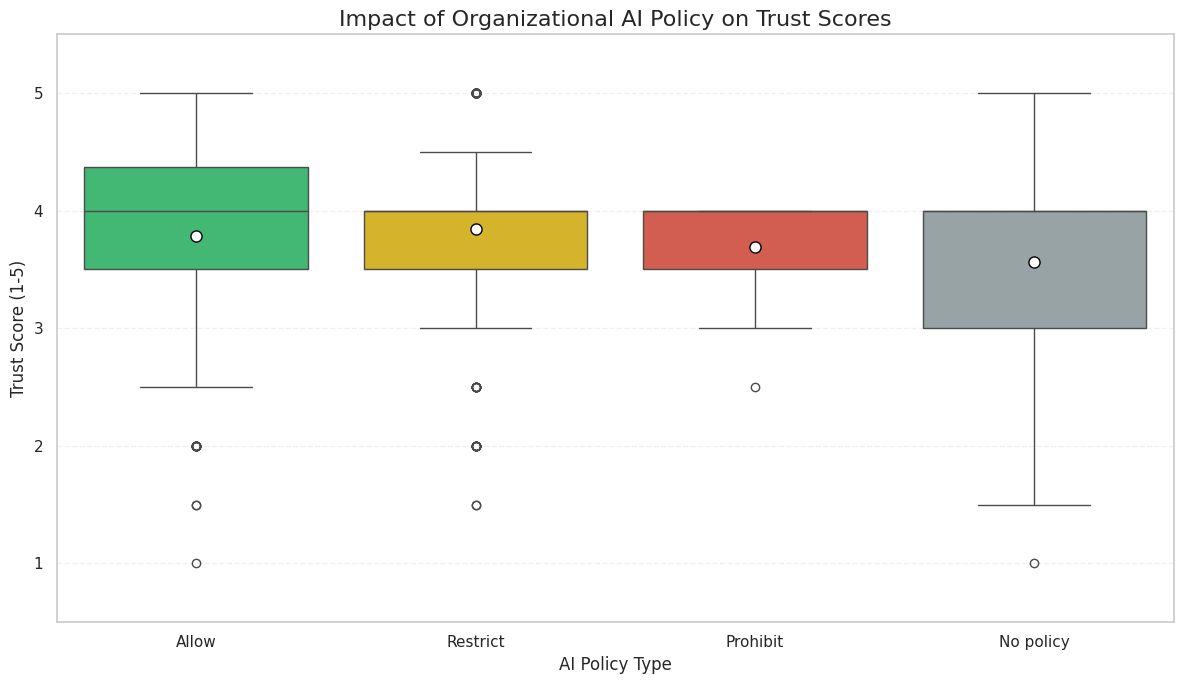

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to ensure we only show the major policy categories
major_policies = ['Allow', 'Restrict', 'Prohibit', 'No policy']
policy_plot_df = df_long[df_long['llmpolice'].isin(major_policies)].copy()

# Define a custom color palette for consistent aesthetics
policy_palette = {
    'Allow': '#2ecc71',   # Green
    'Restrict': '#f1c40f',# Yellow/Orange
    'Prohibit': '#e74c3c',# Red
    'No policy': '#95a5a6' # Grey
}

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=policy_plot_df,
    x='llmpolice',
    y='trust',
    order=major_policies,
    palette=policy_palette,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

plt.title('Impact of Organizational AI Policy on Trust Scores', fontsize=16)
plt.xlabel('AI Policy Type', fontsize=12)
plt.ylabel('Trust Score (1-5)', fontsize=12)
plt.ylim(0.5, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Association analysis: Seniority level, presence of LLM policy, and high trust

In [110]:
df_long

,id,senioritylevel,llmpolice,task,delegated,"in the case of mistakes or failure on this task, someone needs to be held accountable.",a complex or unpredictable environment/situation is likely to cause this task to fail.,failure would result in a substantial negative impact on my life or the lives of others.,risk,i trust the ai/genai/llms' ability to reliably complete the task.,"understanding the reasons behind the ai/genai/llms' actions is important for me to trust the ai/genai/llms on this task (e.g., explanations are necessary).",i trust the ai/genai/llms' actions to protect my interests and align with my values for this task.,trust,presenceOfllmpolicy
0,SP1,Junior,Restrict,code generation,1,2.0,4.0,5.0,4.0,2.0,3.0,3.0,3.0,1
1,SP1,Junior,Restrict,code search,1,2.0,3.0,3.0,3.0,4.0,4.0,4.0,3.5,1
2,SP1,Junior,Restrict,code translation,1,1.0,1.0,1.0,1.0,4.0,3.0,3.0,2.0,1
3,SP1,Junior,Restrict,api recommendation,1,1.0,1.0,1.0,1.0,5.0,5.0,5.0,3.0,1
4,SP1,Junior,Restrict,type inference,1,4.0,4.0,3.0,4.0,3.0,4.0,3.0,3.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,SP160,Senior,Allow,api entity and relation extraction,1,5.0,4.0,4.0,4.0,5.0,4.0,5.0,4.5,1
901,SP160,Senior,Allow,type inference,1,5.0,4.0,2.0,4.0,5.0,1.0,5.0,4.5,1
902,SP160,Senior,Allow,control flow graph generation,1,5.0,4.0,2.0,4.0,5.0,1.0,5.0,4.5,1
903,SP160,Senior,Allow,agile story point estimation,1,2.0,5.0,4.0,4.0,2.0,5.0,2.0,3.0,1


In [111]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from patsy import dmatrices

# 1. Prepare the data
model_df = df_long.dropna(subset=['trust', 'senioritylevel', 'presenceOfllmpolicy', 'id']).copy()
model_df['high_trust'] = (model_df['trust'] >= 4).astype(float)
model_df['senioritylevel'] = pd.Categorical(model_df['senioritylevel'], categories=['Junior', 'Mid-level', 'Senior'])
model_df['presenceOfllmpolicy'] = model_df['presenceOfllmpolicy'].astype(float)

# Create design matrix for fixed effects
y, X = dmatrices("high_trust ~ senioritylevel + presenceOfllmpolicy", data=model_df, return_type='dataframe')

# 2. Setup Random Effects
ids, labels = pd.factorize(model_df['id'])
n_groups = len(labels)
ident = np.arange(n_groups)

exog_vc = np.zeros((len(model_df), n_groups))
for i, group_idx in enumerate(ids):
    exog_vc[i, group_idx] = 1.0

# 3. Fit the Generalized Linear Mixed Model (Logistic)
model = sm.BinomialBayesMixedGLM(y.iloc[:, 0], X, exog_vc=exog_vc, ident=ident)
results = model.fit_vb()

# 4. Display Results
print("Mixed-Effect Logistic Regression: Predicting High Trust (Trust >= 4)")
print(results.summary())

# Fixed effects parameters and their indices
fixed_names = results.model.exog_names
fixed_effects = results.params[:len(fixed_names)]

# Corrected attribute: fe_sd contains the posterior standard deviations for fixed effects
fixed_sds = results.fe_sd

# Calculate Odds Ratios and 95% Credible Intervals
or_df = pd.DataFrame({
    'Posterior Mean': fixed_effects,
    'Odds Ratio': np.exp(fixed_effects),
    '2.5% CI': np.exp(fixed_effects - 1.96 * fixed_sds),
    '97.5% CI': np.exp(fixed_effects + 1.96 * fixed_sds)
}, index=fixed_names)

print("\n--- Odds Ratios and 95% Credible Intervals ---")
print(or_df)

Mixed-Effect Logistic Regression: Predicting High Trust (Trust >= 4)
                        Binomial Mixed GLM Results
                            Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------------------
Intercept                      M    -1.2779   0.0868                      
senioritylevel[T.Mid-level]    M     1.5624   0.1730                      
senioritylevel[T.Senior]       M    -0.0032   0.1291                      
presenceOfllmpolicy            M     1.7255   0.0947                      
VC_1                           V     1.1087   0.4378 3.030   1.262   7.274
VC_2                           V     0.0895   0.5609 1.094   0.356   3.357
VC_3                           V     0.6973   0.4770 2.008   0.774   5.214
VC_4                           V     0.0178   0.5739 1.018   0.323   3.208
VC_5                           V    -0.0541   0.5881 0.947   0.292   3.071
VC_6                           V     0.0178   0.5739 1.

Key takeaways from the analysis:

Seniority: Mid-level developers have significantly higher odds (OR ≈ 4.40) of reporting high trust compared to Juniors.
Policy Presence: The presence of an organizational AI policy is associated with a 3.46x increase in the odds of high trust.

### 1. Check for Multicollinearity (VIF)
We check if our fixed effects are highly correlated, which could inflate standard errors.

In [112]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for the design matrix X (excluding intercept)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

display(vif_data)

,feature,VIF
0,Intercept,10.224441
1,senioritylevel[T.Mid-level],1.609381
2,senioritylevel[T.Senior],1.593975
3,presenceOfllmpolicy,1.017602


### 2. Normality of Random Effects
In a mixed model, we assume the random intercepts (participant effects) are normally distributed.

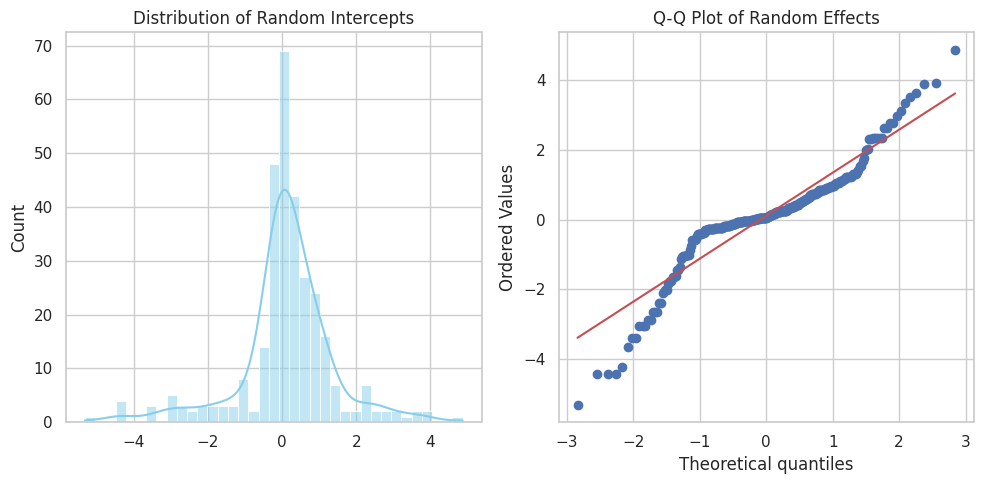

In [114]:
import scipy.stats as stats

# Extract random effects (VC means represent the participant deviations)
# In VB results, these are stored in params after the fixed effects
random_intercepts = results.params[len(fixed_names):]

plt.figure(figsize=(10, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(random_intercepts, kde=True, color='skyblue')
plt.title('Distribution of Random Intercepts')

# Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(random_intercepts, dist="norm", plot=plt)
plt.title('Q-Q Plot of Random Effects')

plt.tight_layout()
plt.show()

### 3. Binned Residual Plot
For logistic regression, standard residual plots are hard to read. We use binned residuals to check if the observed vs. expected proportions align.

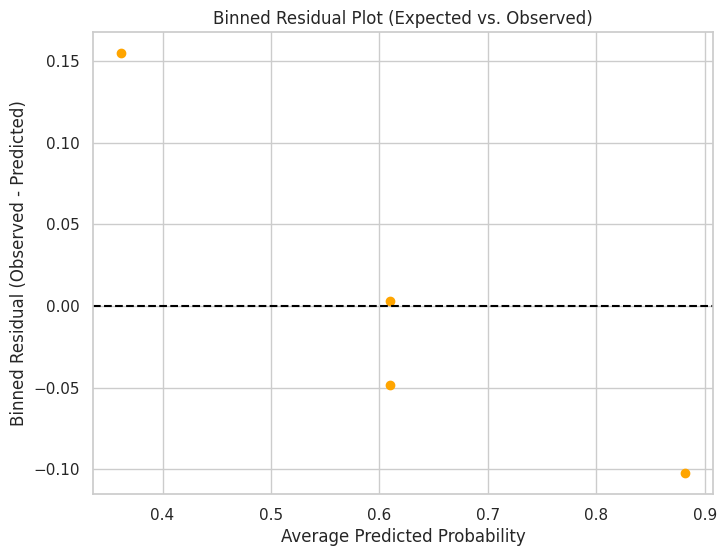

In [115]:
# Calculate predicted probabilities from the model
# results.predict() provides the estimated probabilities (p)
predictions = results.predict()
actuals = y.iloc[:, 0].values

# Create a DataFrame for binning
res_df = pd.DataFrame({'pred': predictions, 'obs': actuals})
res_df['bin'] = pd.qcut(res_df['pred'], q=10, duplicates='drop')

binned_res = res_df.groupby('bin').agg({'pred': 'mean', 'obs': 'mean'}).reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(binned_res['pred'], binned_res['obs'] - binned_res['pred'], color='orange')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Binned Residual Plot (Expected vs. Observed)')
plt.xlabel('Average Predicted Probability')
plt.ylabel('Binned Residual (Observed - Predicted)')
plt.show()